In [4]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [6]:
model = maskrcnn_resnet50_fpn(
    weights=None
)

num_classes = 2

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = \
torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

mask_in_features = \
model.roi_heads.mask_predictor.conv5_mask.in_channels

hidden_layer = 256

model.roi_heads.mask_predictor = \
torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
    mask_in_features,
    hidden_layer,
    num_classes
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/XIS_AI_Project"):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

/content/drive/MyDrive/XIS_AI_Project/models/mask_rcnn_mobile_phone.pth


In [9]:
#load trained weights
model_path = "/content/drive/MyDrive/XIS_AI_Project/models/mask_rcnn_mobile_phone.pth"

model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

model.to(device)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [10]:
import zipfile

zip_path = "/content/drive/MyDrive/XIS_AI_Project/MobilePhoneSegmentation.v1i.coco-segmentation.zip"

extract_dir = "/content/mobile_phone_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [11]:
import os

for root, dirs, files in os.walk("/content/mobile_phone_dataset"):
    print(root)

/content/mobile_phone_dataset
/content/mobile_phone_dataset/test
/content/mobile_phone_dataset/valid
/content/mobile_phone_dataset/train


In [12]:
#loading test images
TEST_DIR = "/content/mobile_phone_dataset/test"

test_images = [
    f for f in os.listdir(TEST_DIR)
    if f.endswith((".jpg", ".jpeg", ".png"))
]

print("Test Images:", len(test_images))
print(test_images)

Test Images: 8
['phone_072_jpeg.rf.e4c5f0dd9b9a0efaba6f42319d6e9c6d.jpg', 'phone_046_jpeg.rf.eaf1e0a4af1f1da36d997fec3fb0ee6b.jpg', 'phone_027_jpeg.rf.576fc0301e48660af9351bd0196752b7.jpg', 'phone_068_jpeg.rf.814bdab64458095aa4b1880d9c9686bf.jpg', 'phone_036_jpeg.rf.cfec9ccb2ecc9fd369993def7a1a14a7.jpg', 'phone_008_jpeg.rf.a8a5d6db77e3a48fc0f167cef938b1b5.jpg', 'phone_064_jpeg.rf.fd4561e6cda736a6e43e952d67caa15a.jpg', 'phone_015_jpeg.rf.baff3aa8d8a3e84ee19848ed8c6c81c7.jpg']


In [13]:
#run inference
image_name = test_images[0]

image_path = os.path.join(
    TEST_DIR,
    image_name
)

image = Image.open(
    image_path
).convert("RGB")

image_tensor = torchvision.transforms.functional.to_tensor(
    image
).to(device)

with torch.no_grad():
    prediction = model([image_tensor])

print(prediction[0].keys())

dict_keys(['boxes', 'labels', 'scores', 'masks'])


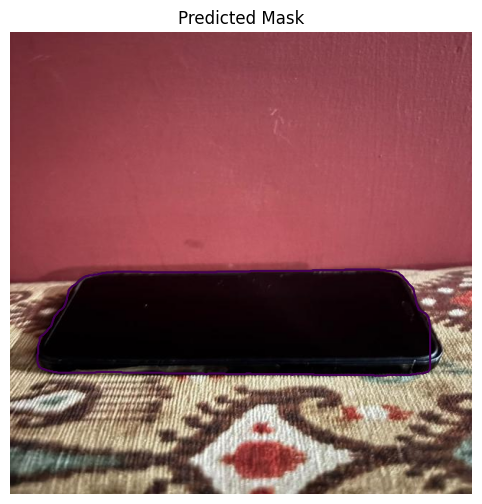

In [14]:
image_np = np.array(image)

plt.figure(figsize=(8,6))
plt.imshow(image_np)

for mask in prediction[0]["masks"]:

    mask = mask[0].cpu().numpy()

    plt.contour(
        mask > 0.5,
        levels=[0.5]
    )

plt.title("Predicted Mask")
plt.axis("off")
plt.show()

Evaluation Metrics

In [15]:
import os

print(os.listdir("/content/mobile_phone_dataset/test"))

['phone_072_jpeg.rf.e4c5f0dd9b9a0efaba6f42319d6e9c6d.jpg', 'phone_046_jpeg.rf.eaf1e0a4af1f1da36d997fec3fb0ee6b.jpg', 'phone_027_jpeg.rf.576fc0301e48660af9351bd0196752b7.jpg', 'phone_068_jpeg.rf.814bdab64458095aa4b1880d9c9686bf.jpg', 'phone_036_jpeg.rf.cfec9ccb2ecc9fd369993def7a1a14a7.jpg', 'phone_008_jpeg.rf.a8a5d6db77e3a48fc0f167cef938b1b5.jpg', '_annotations.coco.json', 'phone_064_jpeg.rf.fd4561e6cda736a6e43e952d67caa15a.jpg', 'phone_015_jpeg.rf.baff3aa8d8a3e84ee19848ed8c6c81c7.jpg']


In [16]:
prediction[0]["scores"]

tensor([0.9991], device='cuda:0')

In [17]:
from pycocotools.coco import COCO

TEST_JSON = "/content/mobile_phone_dataset/test/_annotations.coco.json"

coco_gt = COCO(TEST_JSON)

print("Ground Truth Images:", len(coco_gt.imgs))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Ground Truth Images: 8


In [18]:
#iou function
import numpy as np

def calculate_iou(mask1, mask2):

    intersection = np.logical_and(
        mask1,
        mask2
    )

    union = np.logical_or(
        mask1,
        mask2
    )

    if union.sum() == 0:
        return 0

    return intersection.sum() / union.sum()

In [19]:
#evaluate entire tests set
ious = []

tp = 0
fp = 0
fn = 0

for image_info in coco_gt.imgs.values():

    image_path = os.path.join(
        TEST_DIR,
        image_info["file_name"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = torchvision.transforms.functional.to_tensor(
        image
    ).to(device)

    with torch.no_grad():
        prediction = model([image_tensor])

    pred_masks = prediction[0]["masks"]

    ann_ids = coco_gt.getAnnIds(
        imgIds=image_info["id"]
    )

    anns = coco_gt.loadAnns(
        ann_ids
    )

    if len(anns) == 0:
        continue

    gt_mask = np.zeros(
        (
            image_info["height"],
            image_info["width"]
        ),
        dtype=np.uint8
    )

    for ann in anns:
        gt_mask |= coco_gt.annToMask(
            ann
        )

    if len(pred_masks) > 0:

        pred_mask = (
            pred_masks[0][0]
            .cpu()
            .numpy()
            > 0.5
        )

        iou = calculate_iou(
            gt_mask,
            pred_mask
        )

        ious.append(iou)

        if iou >= 0.5:
            tp += 1
        else:
            fp += 1

    else:

        fn += 1

In [20]:
#calculate metrics
mean_iou = np.mean(ious)

precision = tp / (
    tp + fp + 1e-8
)

recall = tp / (
    tp + fn + 1e-8
)

f1_score = (
    2 * precision * recall
) / (
    precision + recall + 1e-8
)

print("Mean IoU :", round(mean_iou, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1_score, 4))

Mean IoU : 0.9196
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [21]:
results = {
    "Mean IoU": float(mean_iou),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1 Score": float(f1_score)
}

print(results)

{'Mean IoU': 0.9195674621910804, 'Precision': 0.9999999987499999, 'Recall': 0.9999999987499999, 'F1 Score': 0.9999999937499999}


Dimension Estimation


In [23]:
with torch.no_grad():
    prediction = model([image_tensor])[0]

mask = prediction["masks"][0, 0].detach().cpu().numpy()

print(mask.shape)
print(prediction["scores"][0].item())

(640, 640)
0.9980623126029968


In [24]:
import cv2
import numpy as np

binary_mask = (mask > 0.5).astype(np.uint8)

contours, _ = cv2.findContours(
    binary_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

largest_contour = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest_contour)

print("Width (pixels):", w)
print("Height (pixels):", h)

Width (pixels): 504
Height (pixels): 357
